[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-4/map-reduce.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239947-lesson-3-map-reduce)

# Map-reduce

## Review

We're building up to a multi-agent research assistant that ties together all of the modules from this course.

To build this multi-agent assistant, we've been introducing a few LangGraph controllability topics.

We just covered parallelization and sub-graphs.

## Goals

Now, we're going to cover [map reduce](https://langchain-ai.github.io/langgraph/how-tos/map-reduce/).

In [1]:
# %%capture --no-stderr
# %pip install -U langchain_openai langgraph

In [2]:
# import os, getpass

# def _set_env(var: str):
#     if not os.environ.get(var):
#         os.environ[var] = getpass.getpass(f"{var}: ")

# _set_env("OPENAI_API_KEY")

In [3]:
from opentelemetry import trace
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.resources import Resource
from opentelemetry.sdk.trace.export import BatchSpanProcessor
from opentelemetry.exporter.otlp.proto.http.trace_exporter import OTLPSpanExporter

from openinference.instrumentation.langchain import LangChainInstrumentor
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()
OLLAMA_API_KEY = os.getenv("OLLAMA_API_KEY")

In [5]:
# ---------- Tracing ----------
resource = Resource.create({
    "service.name": "agente-ollama-tools",
    "service.version": "1.0.0",
})

provider = TracerProvider(resource=resource)
provider.add_span_processor(
    BatchSpanProcessor(
        OTLPSpanExporter(endpoint="http://localhost:6006/v1/traces")
    )
)
trace.set_tracer_provider(provider)

LangChainInstrumentor().instrument()


In [6]:
import sys
sys.path.append("../")

from config import phoenix_config_

Overriding of current TracerProvider is not allowed
Attempting to instrument while already instrumented
e:\pry_ccchitivo\Courses\Foundation_Introduction_to_LangGraph\lc-academy-env\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'validate_default' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'validate_default' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(


OpenTelemetry Tracing Details
|  Phoenix Project: langchain-academy
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: localhost:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



We'll use [LangSmith](https://docs.smith.langchain.com/) for [tracing](https://docs.smith.langchain.com/concepts/tracing).

In [7]:
# _set_env("LANGSMITH_API_KEY")
# os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

## Problem

Map-reduce operations are essential for efficient task decomposition and parallel processing. 

It has two phases:

(1) `Map` - Break a task into smaller sub-tasks, processing each sub-task in parallel.

(2) `Reduce` - Aggregate the results across all of the completed, parallelized sub-tasks.

Let's design a system that will do two things:

(1) `Map` - Create a set of jokes about a topic.

(2) `Reduce` - Pick the best joke from the list.

We'll use an LLM to do the job generation and selection.

In [25]:
from langchain_openai import ChatOpenAI

# Prompts we will use
subjects_prompt = """Generate a list of 3 sub-topics that are all related to this overall topic: {topic}."""
joke_prompt = """Generate a joke about {subject}"""
best_joke_prompt = """Below are a bunch of jokes about {topic}. Select the best one! Return the ID of the best one, starting 0 as the ID for the first joke. Jokes: \n\n  {jokes}"""

# LLM
# model = ChatOpenAI(model="gpt-4o", temperature=0) 
# model = ChatOllama(model="gemma4:31b",
#                  base_url="https://ollama.com",
#                  client_kwargs={
#                      "headers": {
#                          "Authorization": f"Bearer {os.environ['OLLAMA_API_KEY']}"
#                          }
#                     },
#                  temperature=0
#                  )

model = ChatOllama(model="llama3.2:latest",
                 base_url='http://localhost:11434/',
                 temperature=0.2,
                 ollama_timeout=120
                 )

> A la fecha de hoy 14/ago/2026 Ollama Cloud no soporta `with_structured_output` en cambio Ollama local sí permite pasar un JSON Schema mediate format.


## State

### Parallelizing joke generation

First, let's define the entry point of the graph that will:

* Take a user input topic
* Produce a list of joke topics from it
* Send each joke topic to our above joke generation node

Our state has a `jokes` key, which will accumulate jokes from parallelized joke generation

In [17]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from pydantic import BaseModel

class Subjects(BaseModel):
    subjects: list[str]

class BestJoke(BaseModel):
    id: int
    
class OverallState(TypedDict):
    topic: str
    subjects: list
    jokes: Annotated[list, operator.add]
    best_selected_joke: str

Generate subjects for jokes.

In [18]:
def generate_topics(state: OverallState):
    prompt = subjects_prompt.format(topic=state["topic"])
    response = model.with_structured_output(Subjects).invoke(prompt)
    return {"subjects": response.subjects}

Here is the magic: we use the [Send](https://langchain-ai.github.io/langgraph/concepts/low_level/#send) to create a joke for each subject.

This is very useful! It can automatically parallelize joke generation for any number of subjects.

* `generate_joke`: the name of the node in the graph
* `{"subject": s`}: the state to send

`Send` allow you to pass any state that you want to `generate_joke`! It does not have to align with `OverallState`.

In this case, `generate_joke` is using its own internal state, and we can populate this via `Send`.

In [19]:
from langgraph.types import Send
def continue_to_jokes(state: OverallState):
    return [Send("generate_joke", {"subject": s}) for s in state["subjects"]]

### Joke generation (map)

Now, we just define a node that will create our jokes, `generate_joke`!

We write them back out to `jokes` in `OverallState`! 

This key has a reducer that will combine lists.

In [20]:
class JokeState(TypedDict):
    subject: str

class Joke(BaseModel):
    joke: str

def generate_joke(state: JokeState):
    prompt = joke_prompt.format(subject=state["subject"])
    response = model.with_structured_output(Joke).invoke(prompt)
    return {"jokes": [response.joke]}

### Best joke selection (reduce)

Now, we add logic to pick the best joke.

In [21]:
def best_joke(state: OverallState):
    jokes = "\n\n".join(state["jokes"])
    prompt = best_joke_prompt.format(topic=state["topic"], jokes=jokes)
    response = model.with_structured_output(BestJoke).invoke(prompt)
    return {"best_selected_joke": state["jokes"][response.id]}

## Compile

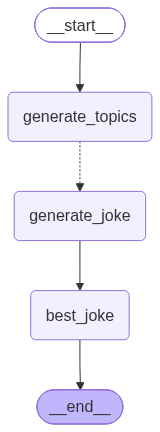

In [22]:
from IPython.display import Image
from langgraph.graph import END, StateGraph, START

# Construct the graph: here we put everything together to construct our graph
graph = StateGraph(OverallState)
graph.add_node("generate_topics", generate_topics)
graph.add_node("generate_joke", generate_joke)
graph.add_node("best_joke", best_joke)
graph.add_edge(START, "generate_topics")
graph.add_conditional_edges("generate_topics", continue_to_jokes, ["generate_joke"])
graph.add_edge("generate_joke", "best_joke")
graph.add_edge("best_joke", END)

# Compile the graph
memory = MemorySaver()
app = graph.compile(checkpointer=memory)
Image(app.get_graph().draw_mermaid_png())

In [28]:
config = {
    "configurable": {
        "thread_id": "36"
    }
}

# Call the graph: here we call it to generate a list of jokes
for s in app.stream({"topic": "dinosaurs"}, config=config):
    print(s)

{'generate_topics': {'subjects': ['Dinosaur Fossil Discovery', 'Dinosaur Behavior and Social Structure', 'Dinosaur Diet and Hunting Strategies']}}
{'generate_joke': {'jokes': ["Why did the Tyrannosaurus Rex go to therapy? Because it had a lot of 'dino-mite' anger issues, but its therapist told it that it needed to work on its 'herd mentality'... turns out, being part of a pack wasn't as easy as it thought!"]}}
{'generate_joke': {'jokes': ['Why did the Velociraptor go to therapy?']}}
{'generate_joke': {'jokes': ['Why did the paleontologist break up with his girlfriend? Because she was always digging up the past!']}}
{'best_joke': {'best_selected_joke': 'Why did the paleontologist break up with his girlfriend? Because she was always digging up the past!'}}


## Studio

**⚠️ DISCLAIMER**

Since the filming of these videos, we've updated Studio so that it can be run locally and opened in your browser. This is now the preferred way to run Studio (rather than using the Desktop App as shown in the video). See documentation [here](https://langchain-ai.github.io/langgraph/concepts/langgraph_studio/#local-development-server) on the local development server and [here](https://langchain-ai.github.io/langgraph/how-tos/local-studio/#run-the-development-server). To start the local development server, run the following command in your terminal in the `/studio` directory in this module:

```
langgraph dev
```

You should see the following output:
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

Open your browser and navigate to the Studio UI: `https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024`.

Let's load our the above graph in the Studio UI, which uses `module-4/studio/map_reduce.py` set in `module-4/studio/langgraph.json`.